## ABC Company Employee Analysis

### Objective

The objective of this project is to preprocess employee data, perform exploratory data analysis, create meaningful visualizations, and derive business insights from the ABC Company employee dataset.

### Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

### Load the Dataset

In [6]:
df = pd.read_excel("ABC Company.xlsx")

In [7]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


### Dataset Information

In [8]:
df.shape

(458, 9)

In [9]:
df.columns

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    str    
 1   Team      458 non-null    str    
 2   Number    458 non-null    int64  
 3   Position  458 non-null    str    
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    str    
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(1), str(4)
memory usage: 32.3+ KB


In [11]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [12]:
df.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

### Data Preprocessing

The dataset is checked for consistency before analysis. According to the project requirements, the Height column is replaced with random values between 150 cm and 180 cm.

In [18]:
# Set a random seed for reproducibility
np.random.seed(42)

In [19]:
df["Height"] = np.random.randint(150, 181, size=len(df))

In [20]:
df["Height"].head()

0    156
1    169
2    178
3    164
4    160
Name: Height, dtype: int32

In [21]:
print("Minimum Height:", df["Height"].min())
print("Maximum Height:", df["Height"].max())

Minimum Height: 150
Maximum Height: 180


### Observation

The Height column has been successfully replaced with randomly generated values ranging from 150 cm to 180 cm as required. The dataset structure remains unchanged with 458 rows and 9 columns.

### Analysis Task 1

#### Distribution of Employees Across Teams

In [22]:
team_count = df["Team"].value_counts()

team_count

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
New York Knicks           16
Milwaukee Bucks           16
Utah Jazz                 16
Boston Celtics            15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Chicago Bulls             15
Cleveland Cavaliers       15
Detroit Pistons           15
Indiana Pacers            15
Dallas Mavericks          15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Charlotte Hornets         15
Miami Heat                15
Washington Wizards        15
Denver Nuggets            15
Oklahoma City Thunder     15
Portland Trail Blazers    15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

In [23]:
team_percentage = (df["Team"].value_counts() / len(df)) * 100

team_percentage

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Utah Jazz                 3.493450
Boston Celtics            3.275109
Brooklyn Nets             3.275109
Philadelphia 76ers        3.275109
Toronto Raptors           3.275109
Golden State Warriors     3.275109
Los Angeles Clippers      3.275109
Los Angeles Lakers        3.275109
Phoenix Suns              3.275109
Sacramento Kings          3.275109
Chicago Bulls             3.275109
Cleveland Cavaliers       3.275109
Detroit Pistons           3.275109
Indiana Pacers            3.275109
Dallas Mavericks          3.275109
Houston Rockets           3.275109
San Antonio Spurs         3.275109
Atlanta Hawks             3.275109
Charlotte Hornets         3.275109
Miami Heat                3.275109
Washington Wizards        3.275109
Denver Nuggets            3.275109
Oklahoma City Thunder     3.275109
Portland Trail Blazers    3.275109
Orlando Magic  

In [24]:
team_distribution = pd.DataFrame({
    "Employee Count": team_count,
    "Percentage": team_percentage.round(2)
})

team_distribution

,Employee Count,Percentage
Team,,
New Orleans Pelicans,19,4.15
Memphis Grizzlies,18,3.93
New York Knicks,16,3.49
Milwaukee Bucks,16,3.49
Utah Jazz,16,3.49
Boston Celtics,15,3.28
Brooklyn Nets,15,3.28
Philadelphia 76ers,15,3.28
Toronto Raptors,15,3.28


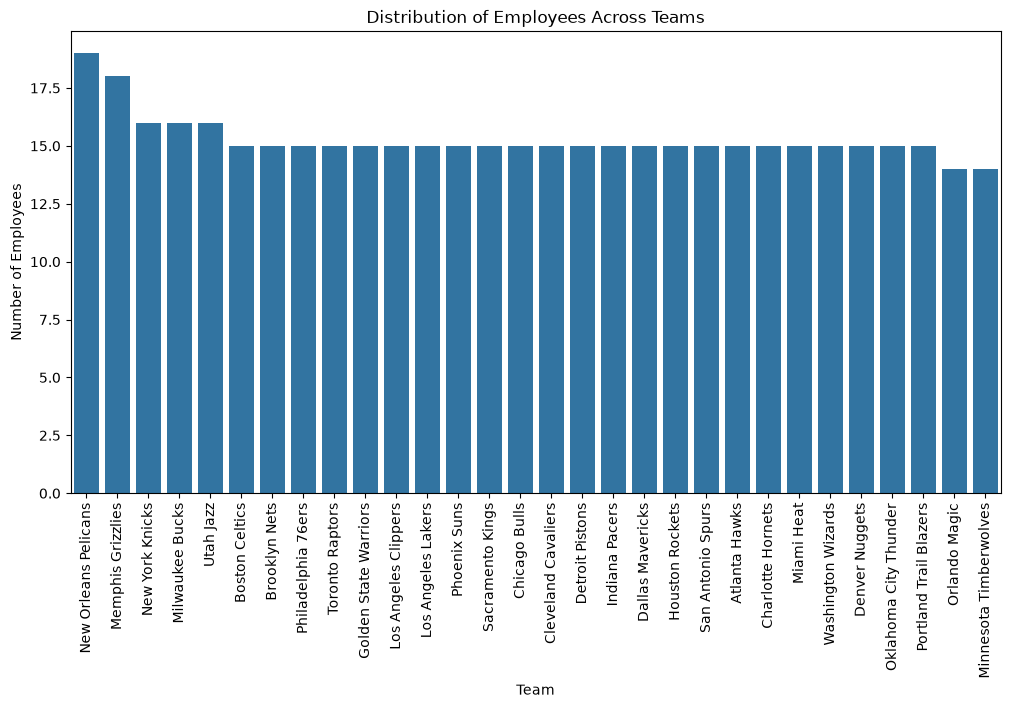

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Team", order=df["Team"].value_counts().index)

plt.title("Distribution of Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")

plt.xticks(rotation=90)

plt.show()

### Observation

The bar chart shows the distribution of employees across different teams. The number of employees is not evenly distributed among the teams. The **New Orleans Pelicans** team has the highest number of employees, with **19 employees**.

In [27]:
print("Team with Highest Employees:")

print(team_count.idxmax())

print()

print("Number of Employees:")

print(team_count.max())

Team with Highest Employees:
New Orleans Pelicans

Number of Employees:
19


### Analysis Task 2

#### Employee Distribution by Position

In [28]:
position_count = df["Position"].value_counts()

position_count

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64

In [29]:
position_distribution = pd.DataFrame({
    "Employee Count": position_count
})

position_distribution

,Employee Count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


In [30]:
print("Position with Highest Employees:")

print(position_count.idxmax())

print()

print("Number of Employees:")

print(position_count.max())

Position with Highest Employees:
SG

Number of Employees:
102


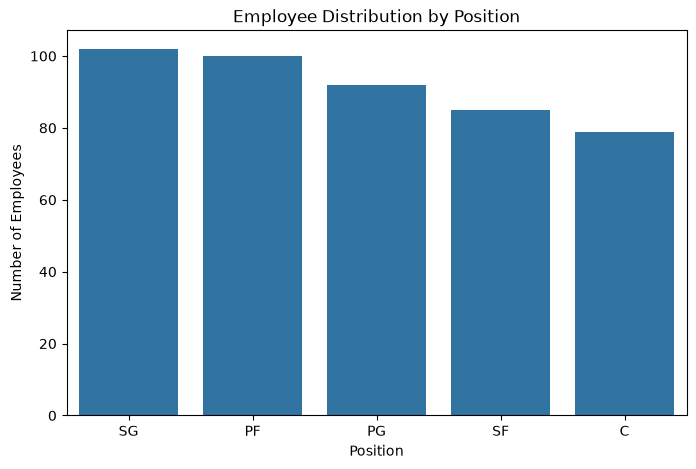

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Position",
    order=df["Position"].value_counts().index
)

plt.title("Employee Distribution by Position")

plt.xlabel("Position")

plt.ylabel("Number of Employees")

plt.show()

### Observation

The chart shows the distribution of employees across different positions. The **SG** has the highest number of employees, indicating that this role is the most common in the company.

### Analysis Task 3

#### Predominant Age Group

In [33]:
# Create age groups
bins = [20, 30, 40, 50, 60]
labels = ["20-29", "30-39", "40-49", "50-59"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

df["Age Group"].value_counts()

Age Group
20-29    334
30-39    119
40-49      3
50-59      0
Name: count, dtype: int64

In [34]:
age_group_count = df["Age Group"].value_counts().sort_index()

age_group_count

Age Group
20-29    334
30-39    119
40-49      3
50-59      0
Name: count, dtype: int64

In [35]:
print("Predominant Age Group:")

print(age_group_count.idxmax())

print()

print("Number of Employees:")

print(age_group_count.max())

Predominant Age Group:
20-29

Number of Employees:
334


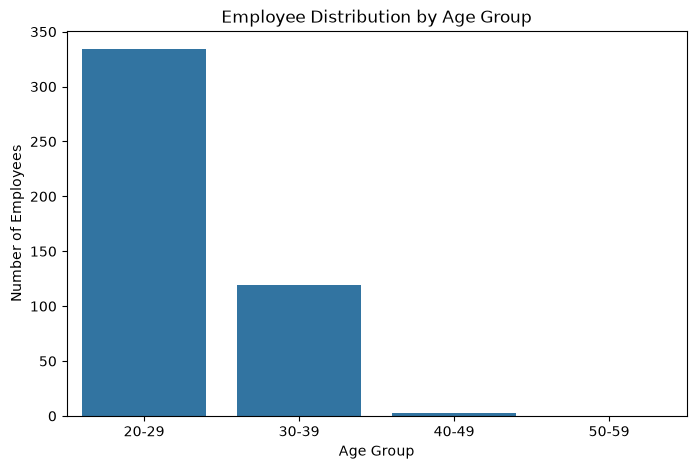

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age Group",
    order=labels
)

plt.title("Employee Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Number of Employees")

plt.show()

### Observation

The employees were grouped into different age categories to identify the predominant age group. The **20–29** age group has the highest number of employees, with **334 employees**, indicating that a large portion of the company's workforce consists of young professionals.

### Analysis Task 4

#### Salary Expenditure by Team and Position

In [38]:
team_salary = df.groupby("Team")["Salary"].sum().sort_values(ascending=False)

team_salary

Team
Cleveland Cavaliers       106988689.0
Los Angeles Clippers       94854640.0
Oklahoma City Thunder      93765298.0
Golden State Warriors      88868997.0
Chicago Bulls              86783378.0
San Antonio Spurs          84442733.0
New Orleans Pelicans       82750774.0
Miami Heat                 82515673.0
Charlotte Hornets          78340920.0
Memphis Grizzlies          76550880.0
Washington Wizards         76328636.0
Houston Rockets            75283021.0
New York Knicks            73303898.0
Atlanta Hawks              72902950.0
Los Angeles Lakers         71770431.0
Sacramento Kings           71683666.0
Dallas Mavericks           71198732.0
Toronto Raptors            71117611.0
Milwaukee Bucks            69603517.0
Detroit Pistons            67168263.0
Indiana Pacers             66751826.0
Utah Jazz                  64007367.0
Phoenix Suns               63445135.0
Orlando Magic              60161470.0
Denver Nuggets             60121930.0
Minnesota Timberwolves     59709697.0
Boston 

In [39]:
print("Team with Highest Salary Expenditure:")

print(team_salary.idxmax())

print()

print("Total Salary:")

print(team_salary.max())

Team with Highest Salary Expenditure:
Cleveland Cavaliers

Total Salary:
106988689.0


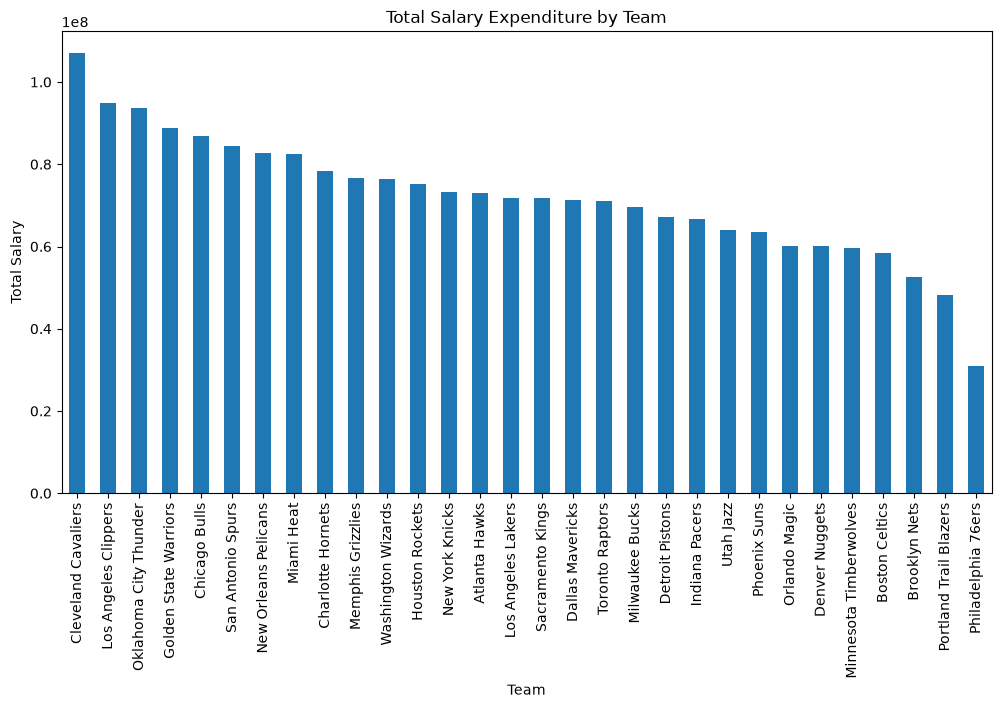

In [40]:
plt.figure(figsize=(12,6))

team_salary.plot(kind="bar")

plt.title("Total Salary Expenditure by Team")

plt.xlabel("Team")

plt.ylabel("Total Salary")

plt.xticks(rotation=90)

plt.show()

In [41]:
position_salary = df.groupby("Position")["Salary"].sum().sort_values(ascending=False)

position_salary

Position
C     466377332.0
PG    446848971.0
PF    442560850.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64

In [42]:
print("Position with Highest Salary Expenditure:")

print(position_salary.idxmax())

print()

print("Total Salary:")

print(position_salary.max())

Position with Highest Salary Expenditure:
C

Total Salary:
466377332.0


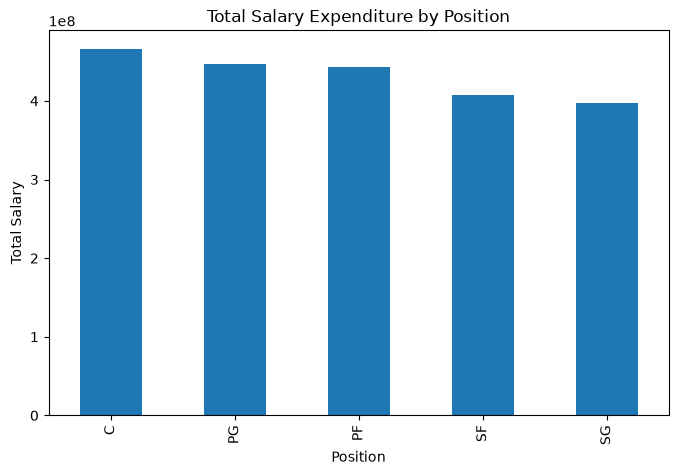

In [43]:
plt.figure(figsize=(8,5))

position_salary.plot(kind="bar")

plt.title("Total Salary Expenditure by Position")

plt.xlabel("Position")

plt.ylabel("Total Salary")

plt.show()

### Observation

The salary expenditure varies across different teams and positions. The **Cleveland Cavaliers** team has the highest total salary expenditure (**106,988,689**), while the **C (Center)** position has the highest salary expenditure (**466,377,332**). This indicates that these categories account for the largest share of the company's payroll expenses.

### Analysis Task 5

#### Correlation Between Age and Salary

In [45]:
correlation = df["Age"].corr(df["Salary"])

print("Correlation between Age and Salary:", correlation)

Correlation between Age and Salary: 0.2140094122657097


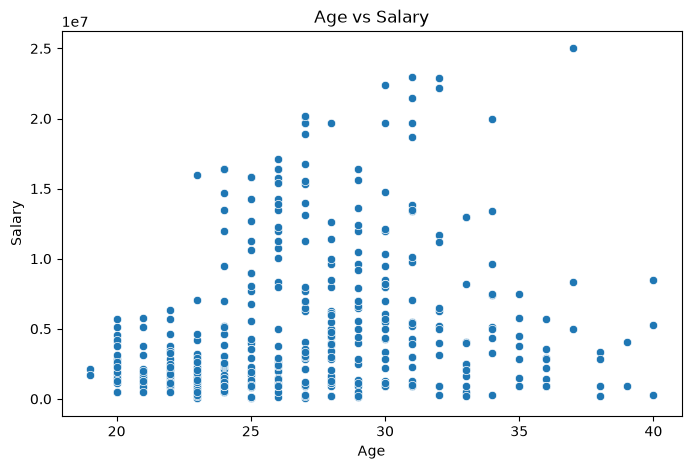

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Salary"
)

plt.title("Age vs Salary")

plt.xlabel("Age")

plt.ylabel("Salary")

plt.show()

### Observation

The scatter plot shows the relationship between employee age and salary. The correlation coefficient is **0.214**, indicating a **weak positive correlation** between age and salary. This suggests that salary tends to increase slightly with age, but the relationship is not strong.

### Data Story

The ABC Company employee dataset was successfully preprocessed and analyzed to understand workforce distribution and salary patterns.

### Key Insights

- The Height column was corrected by replacing it with random values between **150 cm and 180 cm**, ensuring data consistency.
- Employee distribution varies across teams. The **New Orleans Pelicans** have the highest number of employees (**19**).
- The **SG (Shooting Guard)** position is the most common role, with **102 employees**.
- Most employees belong to the **20–29** age group, accounting for **334 employees**, indicating a predominantly young workforce.
- The **Cleveland Cavaliers** have the highest total salary expenditure among all teams.
- The **Center (C)** position accounts for the highest salary expenditure among all positions.
- The correlation between age and salary is **0.214**, indicating a weak positive relationship between the two variables.

Overall, the analysis provides valuable insights into employee distribution, workforce demographics, and salary allocation within the company.

### Conclusion

This project successfully demonstrated the complete data analysis workflow using Python.

The dataset was preprocessed, explored, analyzed, and visualized using **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn**. The analysis identified workforce distribution across teams and positions, the predominant employee age group, salary expenditure patterns, and the relationship between age and salary.

This project enhanced practical skills in data preprocessing, exploratory data analysis (EDA), data visualization, and business insight generation, providing a strong foundation for future data science projects.